<a href="https://colab.research.google.com/github/bahmedx/730/blob/main/Image_Classification_with_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Image Classification with Convolutional Neural Networks using CIFAR-10**
**Objective**

The objective of this project is to develop and evaluate Convolutional Neural Network (CNN) models for image classification using the CIFAR-10 dataset. The project investigates the impact of data augmentation, batch normalization, dropout regularizat

**Import Libraries**

In [3]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, random_split

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")
print(f"PyTorch Version: {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")

Libraries imported successfully.


**Reproducibility**

In [4]:
# Set seed for reproducibility

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


**Data Loading & Preprocessing**

In [5]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

full_train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

classes = (
    "plane",
    "car",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
)

print("Train Samples:", len(train_dataset))
print("Validation Samples:", len(val_dataset))
print("Test Samples:", len(test_dataset))

100%|██████████| 170M/170M [40:36<00:00, 70.0kB/s]


Train Samples: 40000
Validation Samples: 10000
Test Samples: 10000


**Baseline CNN Architecture**

In [13]:
class ConvNet(nn.Module):

    def __init__(self, num_classes=10, dropout_rate=0.3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    print("Baseline CNN architecture defined successfully.")

Baseline CNN architecture defined successfully.


**Alternative CNN Architecture**

In [27]:
class DeepConvNet(nn.Module):

    def __init__(self, num_classes=10, dropout_rate=0.5):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    print("Deep CNN architecture defined successfully.")

Deep CNN architecture defined successfully.


**Evaluation Function**

In [31]:
def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / total
    accuracy = 100 * correct / total

    return (
        avg_loss,
        accuracy,
        np.array(all_preds),
        np.array(all_labels)
    )

print("Evaluation function defined successfully.")

Evaluation function defined successfully.


**Training Function**

In [37]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    epochs=5
):

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    print("Training started...\n")

    for epoch in range(epochs):

        print(f"Starting Epoch {epoch + 1}/{epochs}")

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (images, labels) in enumerate(train_loader):

            if batch_idx % 50 == 0:
                print(
                    f"Epoch {epoch + 1} | "
                    f"Batch {batch_idx}/{len(train_loader)}"
                )

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc = 100 * correct / total

        val_loss, val_acc, _, _ = evaluate(
            model,
            val_loader,
            criterion
        )

        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch + 1:02d}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.2f}%"
        )

    print("\nTraining completed successfully.")

    return history

**Train Baseline CNN**

In [41]:
import time

print("=" * 60)
print("STARTING BASELINE CNN TRAINING")
print("=" * 60)

# Initialize Model
model = ConvNet(dropout_rate=0.3).to(device)

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=5
)

# Start Timer
start_time = time.time()

# Train Model
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=3
)

# End Timer
end_time = time.time()

# Training Summary
print("\n" + "=" * 60)
print("BASELINE CNN TRAINING COMPLETED")
print("=" * 60)
print(f"Training Time: {(end_time - start_time) / 60:.2f} minutes")
print(f"Final Training Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"Final Validation Accuracy: {history['val_acc'][-1]:.2f}%")
print("=" * 60)

STARTING BASELINE CNN TRAINING
Training started...

Starting Epoch 1/5
Epoch 1 | Batch 0/625
Epoch 1 | Batch 50/625
Epoch 1 | Batch 100/625
Epoch 1 | Batch 150/625
Epoch 1 | Batch 200/625
Epoch 1 | Batch 250/625
Epoch 1 | Batch 300/625
Epoch 1 | Batch 350/625
Epoch 1 | Batch 400/625
Epoch 1 | Batch 450/625
Epoch 1 | Batch 500/625
Epoch 1 | Batch 550/625
Epoch 1 | Batch 600/625
Epoch [01/5] | Train Loss: 1.3301 | Train Acc: 51.99% | Val Loss: 1.1487 | Val Acc: 58.75%
Starting Epoch 2/5
Epoch 2 | Batch 0/625
Epoch 2 | Batch 50/625
Epoch 2 | Batch 100/625
Epoch 2 | Batch 150/625
Epoch 2 | Batch 200/625
Epoch 2 | Batch 250/625
Epoch 2 | Batch 300/625
Epoch 2 | Batch 350/625
Epoch 2 | Batch 400/625
Epoch 2 | Batch 450/625
Epoch 2 | Batch 500/625
Epoch 2 | Batch 550/625
Epoch 2 | Batch 600/625
Epoch [02/5] | Train Loss: 0.9356 | Train Acc: 67.24% | Val Loss: 0.8465 | Val Acc: 70.45%
Starting Epoch 3/5
Epoch 3 | Batch 0/625
Epoch 3 | Batch 50/625
Epoch 3 | Batch 100/625
Epoch 3 | Batch 150/62

**Final Test Evaluation**

In [42]:
test_loss, test_acc, preds, labels = evaluate(
    model,
    test_loader,
    criterion
)

precision = precision_score(
    labels,
    preds,
    average="macro"
)

recall = recall_score(
    labels,
    preds,
    average="macro"
)

f1 = f1_score(
    labels,
    preds,
    average="macro"
)

print("\nFINAL TEST RESULTS")
print(f"Accuracy : {test_acc:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nCLASSIFICATION REPORT\n")

print(
    classification_report(
        labels,
        preds,
        target_names=classes
    )
)


FINAL TEST RESULTS
Accuracy : 81.24%
Precision: 0.8139
Recall   : 0.8124
F1 Score : 0.8125

CLASSIFICATION REPORT

              precision    recall  f1-score   support

       plane       0.81      0.83      0.82      1000
         car       0.92      0.92      0.92      1000
        bird       0.75      0.68      0.71      1000
         cat       0.66      0.66      0.66      1000
        deer       0.78      0.81      0.80      1000
         dog       0.70      0.79      0.74      1000
        frog       0.84      0.87      0.85      1000
       horse       0.87      0.82      0.84      1000
        ship       0.90      0.88      0.89      1000
       truck       0.91      0.88      0.89      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



**Evaluation Metrics & Visualization**

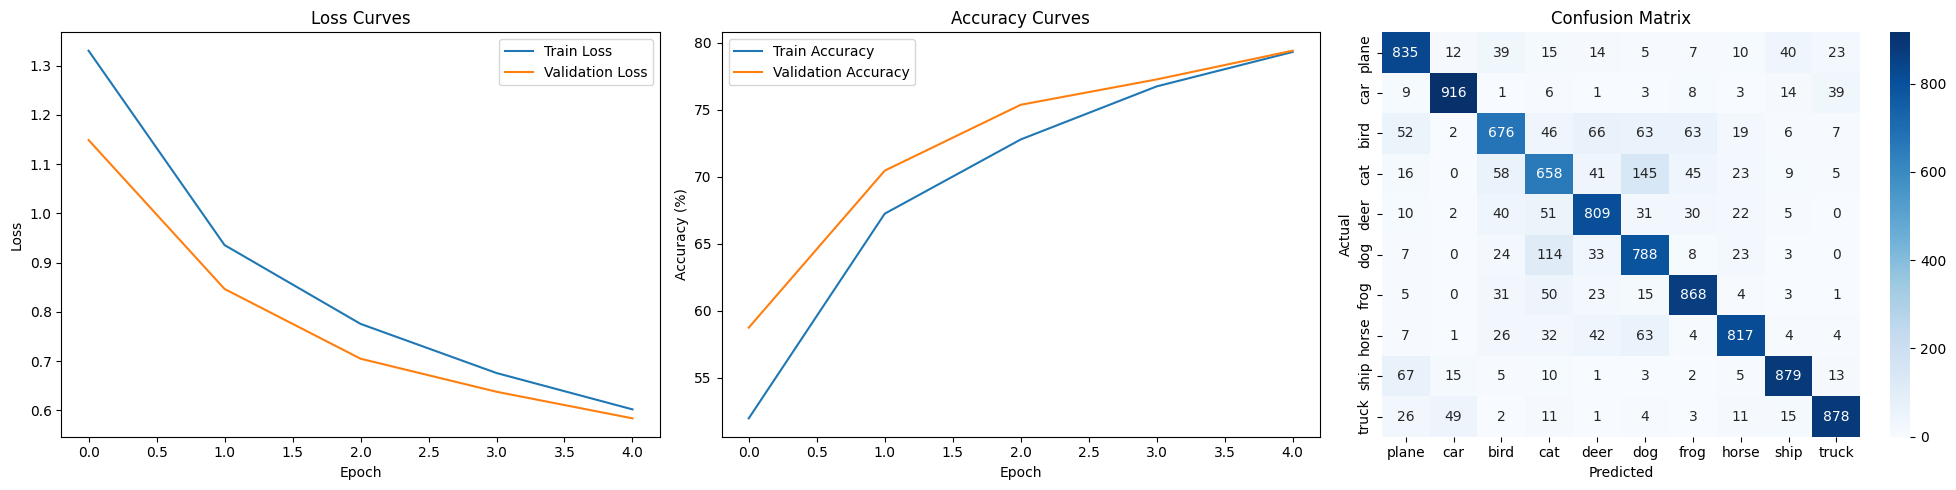

In [43]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5)
)

# Loss Curves

axes[0].plot(
    history["train_loss"],
    label="Train Loss"
)

axes[0].plot(
    history["val_loss"],
    label="Validation Loss"
)

axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy Curves

axes[1].plot(
    history["train_acc"],
    label="Train Accuracy"
)

axes[1].plot(
    history["val_acc"],
    label="Validation Accuracy"
)

axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()

# Confusion Matrix

cm = confusion_matrix(
    labels,
    preds
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    ax=axes[2]
)

axes[2].set_title("Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

**Train Deep CNN**

In [51]:
print("Training Alternative Deep CNN...\n")

deep_model = DeepConvNet(
    dropout_rate=0.5
).to(device)

deep_optimizer = optim.Adam(
    deep_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

deep_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    deep_optimizer,
    T_max=5
)

deep_history = train_model(
    deep_model,
    train_loader,
    val_loader,
    criterion,
    deep_optimizer,
    deep_scheduler,
    epochs=1
)

print("\nDeep CNN Training Completed")

Training Alternative Deep CNN...

Training started...

Starting Epoch 1/1
Epoch 1 | Batch 0/625
Epoch 1 | Batch 50/625
Epoch 1 | Batch 100/625
Epoch 1 | Batch 150/625
Epoch 1 | Batch 200/625
Epoch 1 | Batch 250/625
Epoch 1 | Batch 300/625
Epoch 1 | Batch 350/625
Epoch 1 | Batch 400/625
Epoch 1 | Batch 450/625
Epoch 1 | Batch 500/625
Epoch 1 | Batch 550/625
Epoch 1 | Batch 600/625
Epoch [01/1] | Train Loss: 1.7152 | Train Acc: 35.14% | Val Loss: 1.4456 | Val Acc: 46.14%

Training completed successfully.

Deep CNN Training Completed


**Evaluate Deep CNN**

In [52]:
deep_loss, deep_acc, deep_preds, deep_labels = evaluate(
    deep_model,
    test_loader,
    criterion
)

deep_precision = precision_score(
    deep_labels,
    deep_preds,
    average="macro"
)

deep_recall = recall_score(
    deep_labels,
    deep_preds,
    average="macro"
)

deep_f1 = f1_score(
    deep_labels,
    deep_preds,
    average="macro"
)

print("\nDEEP CNN RESULTS")

print(f"Accuracy : {deep_acc:.2f}%")
print(f"Precision: {deep_precision:.4f}")
print(f"Recall   : {deep_recall:.4f}")
print(f"F1 Score : {deep_f1:.4f}")


DEEP CNN RESULTS
Accuracy : 46.67%
Precision: 0.5253
Recall   : 0.4667
F1 Score : 0.4577


**Model Comparison Table**

In [53]:
comparison_df = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Deep CNN"
    ],
    "Accuracy": [
        test_acc,
        deep_acc
    ],
    "Precision": [
        precision,
        deep_precision
    ],
    "Recall": [
        recall,
        deep_recall
    ],
    "F1 Score": [
        f1,
        deep_f1
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline CNN,81.24,0.813871,0.8124,0.812514
1,Deep CNN,46.67,0.525302,0.4667,0.457723


**Model Comparison Visualization**

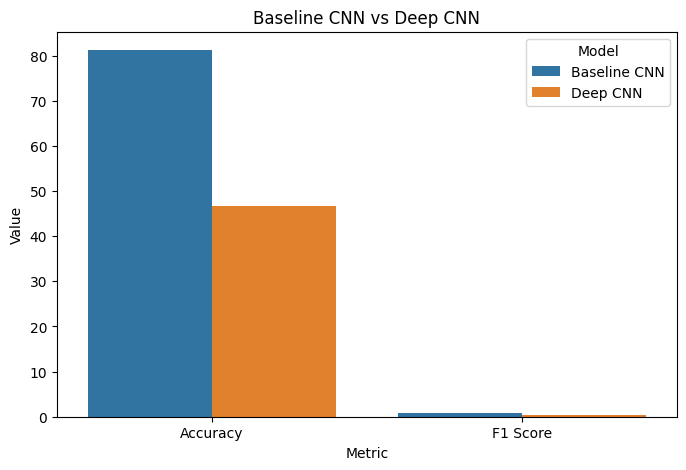

In [54]:
plt.figure(figsize=(8,5))

comparison_plot = comparison_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "F1 Score"],
    var_name="Metric",
    value_name="Value"
)

sns.barplot(
    data=comparison_plot,
    x="Metric",
    y="Value",
    hue="Model"
)

plt.title("Baseline CNN vs Deep CNN")
plt.show()

print("\nBaseline CNN vs Deep CNN")

**Hyperparameter Tuning**

In [57]:
experiments = [

    {
        "name":"Adam LR=0.001",
        "optimizer":"Adam",
        "lr":0.001,
        "dropout":0.5
    },

    {
        "name":"SGD LR=0.01",
        "optimizer":"SGD",
        "lr":0.01,
        "dropout":0.5
    },

    {
        "name":"Adam No Dropout",
        "optimizer":"Adam",
        "lr":0.001,
        "dropout":0.0
    }
]

**Hyperparameter Experiments**

In [58]:
results = []

for exp in experiments:

    print(f"\nRunning Experiment: {exp['name']}")

    model_exp = DeepConvNet(
        dropout_rate=exp["dropout"]
    ).to(device)

    if exp["optimizer"] == "Adam":

        optimizer_exp = optim.Adam(
            model_exp.parameters(),
            lr=exp["lr"],
            weight_decay=1e-4
        )

    else:

        optimizer_exp = optim.SGD(
            model_exp.parameters(),
            lr=exp["lr"],
            momentum=0.9,
            weight_decay=1e-4
        )

    scheduler_exp = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_exp,
        T_max=5
    )

    train_model(
        model_exp,
        train_loader,
        val_loader,
        criterion,
        optimizer_exp,
        scheduler_exp,
        epochs=2
    )

    _, acc, preds_exp, labels_exp = evaluate(
        model_exp,
        test_loader,
        criterion
    )

    f1_exp = f1_score(
        labels_exp,
        preds_exp,
        average="macro"
    )

    results.append({
        "Experiment": exp["name"],
        "Accuracy": acc,
        "F1 Score": f1_exp
    })


Running Experiment: Adam LR=0.001
Training started...

Starting Epoch 1/2
Epoch 1 | Batch 0/625
Epoch 1 | Batch 50/625
Epoch 1 | Batch 100/625
Epoch 1 | Batch 150/625
Epoch 1 | Batch 200/625
Epoch 1 | Batch 250/625
Epoch 1 | Batch 300/625
Epoch 1 | Batch 350/625
Epoch 1 | Batch 400/625
Epoch 1 | Batch 450/625
Epoch 1 | Batch 500/625
Epoch 1 | Batch 550/625
Epoch 1 | Batch 600/625
Epoch [01/2] | Train Loss: 1.6919 | Train Acc: 36.51% | Val Loss: 1.3503 | Val Acc: 50.29%
Starting Epoch 2/2
Epoch 2 | Batch 0/625
Epoch 2 | Batch 50/625
Epoch 2 | Batch 100/625
Epoch 2 | Batch 150/625
Epoch 2 | Batch 200/625
Epoch 2 | Batch 250/625
Epoch 2 | Batch 300/625
Epoch 2 | Batch 350/625
Epoch 2 | Batch 400/625
Epoch 2 | Batch 450/625
Epoch 2 | Batch 500/625
Epoch 2 | Batch 550/625
Epoch 2 | Batch 600/625
Epoch [02/2] | Train Loss: 1.3250 | Train Acc: 51.97% | Val Loss: 1.1241 | Val Acc: 59.07%

Training completed successfully.

Running Experiment: SGD LR=0.01
Training started...

Starting Epoch 1/2

**Hyperparameter Results & Visualization**

Hyperparameter Experiment Results


,Experiment,Accuracy,F1 Score
2,Adam No Dropout,64.17,0.624989
0,Adam LR=0.001,60.67,0.604557
1,SGD LR=0.01,56.33,0.555866


/tmp/ipykernel_3295/4135058682.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3295/4135058682.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


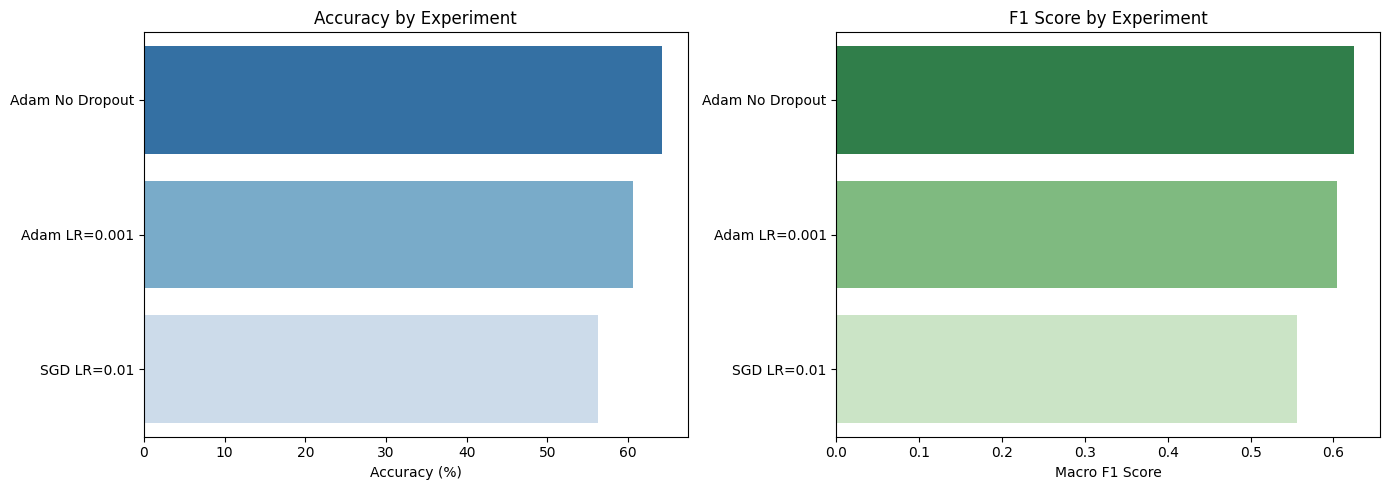

In [59]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("Hyperparameter Experiment Results")

display(results_df)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Experiment",
    palette="Blues_r",
    ax=axes[0]
)

axes[0].set_title("Accuracy by Experiment")
axes[0].set_xlabel("Accuracy (%)")
axes[0].set_ylabel("")

sns.barplot(
    data=results_df,
    x="F1 Score",
    y="Experiment",
    palette="Greens_r",
    ax=axes[1]
)

axes[1].set_title("F1 Score by Experiment")
axes[1].set_xlabel("Macro F1 Score")
axes[1].set_ylabel("")

plt.tight_layout()

plt.show()

**Best Hyperparameter Configuration**

In [60]:
best_model = results_df.iloc[0]

print("Best Hyperparameter Configuration")
print("----------------------------------")
print(f"Experiment : {best_model['Experiment']}")
print(f"Accuracy   : {best_model['Accuracy']:.2f}%")
print(f"F1 Score   : {best_model['F1 Score']:.4f}")

Best Hyperparameter Configuration
----------------------------------
Experiment : Adam No Dropout
Accuracy   : 64.17%
F1 Score   : 0.6250
